## CODEX GBM — StarDist prediction visualization

Twin of `CODEX_hcc/Pred_statistic_visual_hcc_all.ipynb` / `Xenium_lung/Pred_statistic_visual_xenium_all.ipynb`.

The 10x breast preview has **no clinical groups**. This notebook:

1. Plots **pooled StarDist ROC** for L2 / L12 / L1 on `P174511_Initial` + `P179161_Recurrent`.
2. Compares **per-replicate macro AUROC**.

Requires cross-dataset outputs under `data/CODEX/GBM/Results/result_all_spatial/stardist/`.

```bash
python -u code/CODEX_gbm/GBM_train_validate_cv_UNIlabel.py \
  --mode cross-dataset --use-spatial-context --spatial-k 8 --spatial-mode mean \
  --pooled-save-result result_all_spatial
```


In [1]:
import matplotlib
matplotlib.rcParams["pdf.fonttype"] = 42
matplotlib.rcParams["ps.fonttype"] = 42

import sys
import warnings
import logging
from pathlib import Path

warnings.filterwarnings("ignore")
logging.getLogger("ome_zarr").setLevel(logging.ERROR)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

REPO = Path("/home/lingyu/ssd2/Python/Hist2Pheno")
for _p in (REPO / "code" / "Hist2Pheno_pkg", REPO / "code" / "CODEX_gbm"):
    if str(_p) not in sys.path:
        sys.path.insert(0, str(_p))

PAN_ORGAN = "codex_gbm"
GBM_ROOT = REPO / "data" / "CODEX" / "GBM"
DATA_ROOT = GBM_ROOT / "Results"
STARDIST_RESULT_ROOT = DATA_ROOT / "result_all_spatial" / "stardist"
OUT_DIR = DATA_ROOT / "result_all_spatial" / "pred_viz"
OUT_DIR.mkdir(parents=True, exist_ok=True)
SAMPLES = ["P174511_Initial", "P179161_Recurrent"]
TIERS = ("l2", "l12", "l1")

print("DATA_ROOT:", DATA_ROOT)
print("STARDIST :", STARDIST_RESULT_ROOT)
print("OUT_DIR  :", OUT_DIR)
print("exists   :", STARDIST_RESULT_ROOT.is_dir())


DATA_ROOT: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Results
STARDIST : /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Results/result_all_spatial/stardist
OUT_DIR  : /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Results/result_all_spatial/pred_viz
exists   : True


## Pooled StarDist ROC (P174511_Initial + P179161_Recurrent)

Uses `uni_label_cv_helpers.plot_pooled_stardist_tier_rocs` on the cross-dataset StarDist folders.


Linked 2/2 StarDist sample dirs under /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Results/result_all_spatial/pred_viz/_tmp_selected_stardist

=== L2 | discovering validation_external_stardist_matched_AUROC.csv ===
  P174511_Initial: 37,369 cells, 16 local classes
  P179161_Recurrent: 133,433 cells, 16 local classes
Saved pooled AUROC concat: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Results/result_all_spatial/pred_viz/validation_external_stardist_matched_AUROC_all_samples_concat.csv (170,802 rows)
Saved global class names: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Results/result_all_spatial/pred_viz/validation_external_stardist_matched_AUROC_all_samples_class_names.csv (16 classes)
Pooled: 170,802 cells from 2 samples; 16 global final_CT classes
  ROC colors: codex_gbm_fine (aligned with dataset spatial palette).
  ✓ Saved ROC figure: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Results/result_all_spatial/pred_viz/roc_stardist_l2_cross_dataset_all_Complet

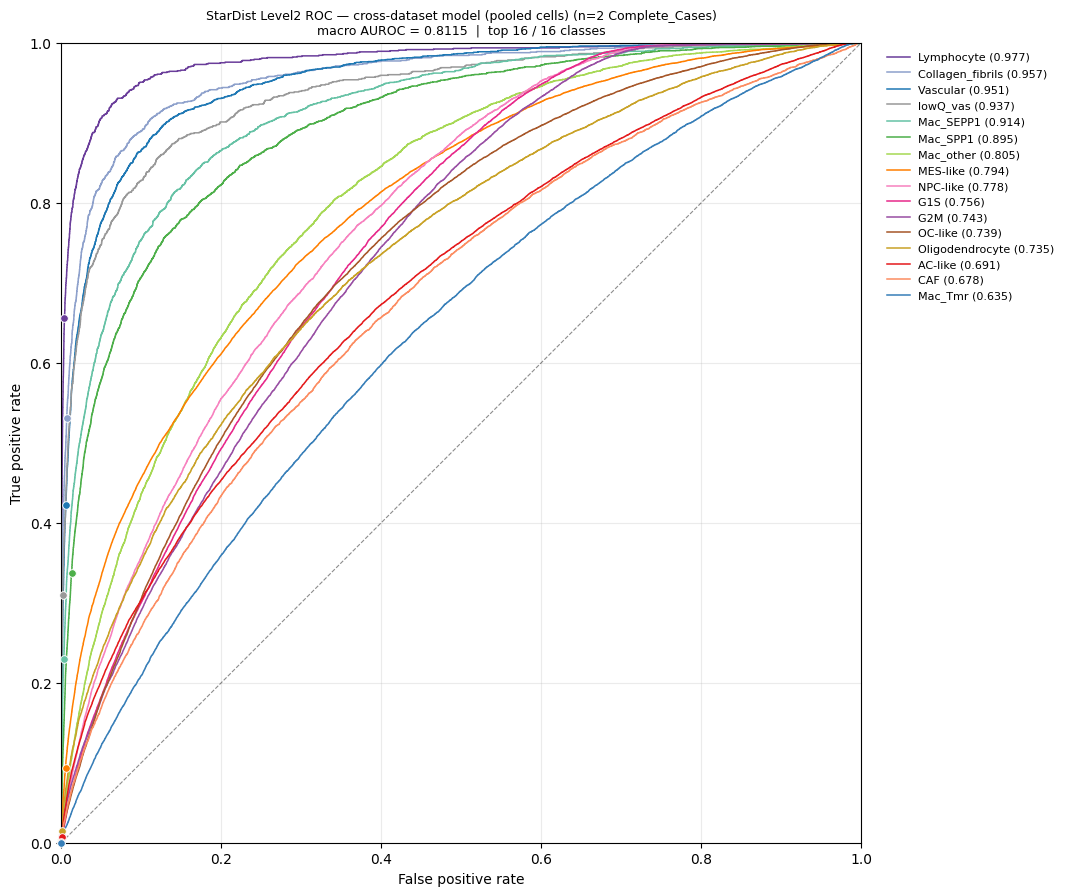

Pooled macro AUROC (L2): 0.8115

=== L12 | discovering validation_external_stardist_matched_AUROC_level12.csv ===
  P174511_Initial: 37,369 cells, 9 local classes
  P179161_Recurrent: 133,433 cells, 9 local classes
Saved pooled AUROC concat: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Results/result_all_spatial/pred_viz/validation_external_stardist_matched_AUROC_level12_all_samples_concat.csv (170,802 rows)
Saved global class names: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Results/result_all_spatial/pred_viz/validation_external_stardist_matched_AUROC_level12_all_samples_class_names.csv (9 classes)
Pooled: 170,802 cells from 2 samples; 9 global final_sublineage classes
  ROC colors: codex_gbm_intermediate (aligned with dataset spatial palette).
  ✓ Saved ROC figure: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Results/result_all_spatial/pred_viz/roc_stardist_l12_cross_dataset_all_Complete_Cases_pooled.pdf


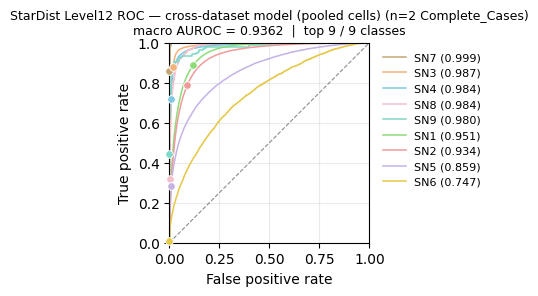

Pooled macro AUROC (L12): 0.9362

=== L1 | discovering validation_external_stardist_matched_AUROC_level1.csv ===
  P174511_Initial: 37,369 cells, 5 local classes
  P179161_Recurrent: 133,433 cells, 5 local classes
Saved pooled AUROC concat: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Results/result_all_spatial/pred_viz/validation_external_stardist_matched_AUROC_level1_all_samples_concat.csv (170,802 rows)
Saved global class names: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Results/result_all_spatial/pred_viz/validation_external_stardist_matched_AUROC_level1_all_samples_class_names.csv (5 classes)
Pooled: 170,802 cells from 2 samples; 5 global final_lineage classes
  ROC colors: codex_gbm_coarse (aligned with dataset spatial palette).
  ✓ Saved ROC figure: /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Results/result_all_spatial/pred_viz/roc_stardist_l1_cross_dataset_all_Complete_Cases_pooled.pdf


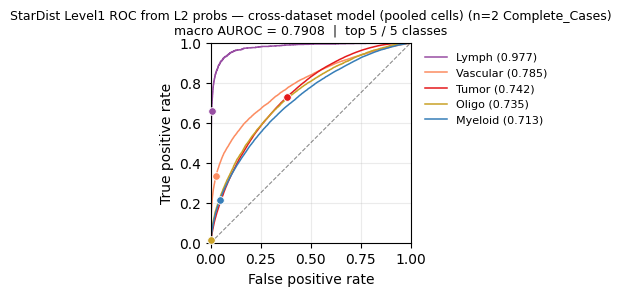

Pooled macro AUROC (L1): 0.7908
Wrote pooled ROC for: ['l2', 'l12', 'l1']


In [2]:
import importlib
import uni_label_cv_helpers as uni_nb

importlib.reload(uni_nb)
from uni_label_cv_helpers import (
    plot_pooled_stardist_tier_rocs,
    symlink_stardist_sample_dirs,
    build_stardist_sample_macro_auroc_table,
    stardist_per_class_table_from_auroc_csv,
    stardist_auroc_tier_spec,
)

filtered_root = symlink_stardist_sample_dirs(
    STARDIST_RESULT_ROOT,
    SAMPLES,
    OUT_DIR / "_tmp_selected_stardist",
)

pooled_roc = plot_pooled_stardist_tier_rocs(
    filtered_root,
    OUT_DIR,
    TIERS,
    layout="pooled_stardist",
    pan_organ=PAN_ORGAN,
    figsize={"l12": (2.0, 2.0), "l1": (2.0, 2.0)},
)
print("Wrote pooled ROC for:", list(pooled_roc))


## Per-replicate macro AUROC

One row per sample (`P174511_Initial`, `P179161_Recurrent`) and three-head columns `macro_auc_l2` / `macro_auc_l12` / `macro_auc_l1`.

If Recurrent sits near 0.5 while Initial is high, the StarDist checkpoint was likely the **leave-one-replicate-out** fold trained only on Initial. Recurrent has extra L2 classes (`G1S`, `G2M`, `NPC-like`) and SN labels (`SN3`, `SN4`, `SN7`) that Initial never sees. Re-run pooled train after the all-sample refit so both slides share a checkpoint that saw every class.


,Sample,macro_auc_l2,macro_auc_l12,macro_auc_l1
0,P174511_Initial,0.817151,0.890420,0.786366
1,P179161_Recurrent,0.789934,0.918894,0.789303


Wrote /home/lingyu/ssd2/Python/Hist2Pheno/data/CODEX/GBM/Results/result_all_spatial/pred_viz/stardist_macro_auroc_by_replicate.csv


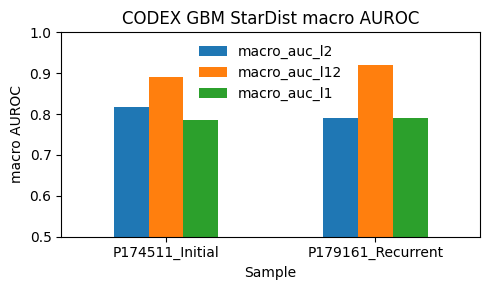

In [3]:
auroc_tbl = build_stardist_sample_macro_auroc_table(
    filtered_root,
    tiers=TIERS,
    layout="pooled_stardist",
)
out_csv = OUT_DIR / "stardist_macro_auroc_by_replicate.csv"
if len(auroc_tbl):
    auroc_tbl.to_csv(out_csv, index=False)
    display(auroc_tbl)
    print("Wrote", out_csv)

    plot_df = auroc_tbl.set_index("Sample")
    cols = [c for c in plot_df.columns if c.startswith("macro_auc_")]
    ax = plot_df[cols].plot(kind="bar", figsize=(5, 3), rot=0)
    ax.set_ylabel("macro AUROC")
    ax.set_ylim(0.5, 1.0)
    ax.legend(frameon=False)
    ax.set_title("CODEX GBM StarDist macro AUROC")
    fig = ax.get_figure()
    fig.tight_layout()
    fig.savefig(OUT_DIR / "stardist_macro_auroc_by_replicate.pdf")
    plt.show()
else:
    print("No AUROC CSVs yet. Run the cross-dataset CLI / all notebook first.")


## Why Recurrent looks near-random

Cross-dataset CV with **two slides** is leave-one-replicate-out. `random_state=42` fold 0 trains on **Initial only** and holds out Recurrent. That fold cannot emit Rec-private labels:

- L2: `G1S`, `G2M`, `NPC-like` (about one third of Rec nuclei)
- L12: `SN3`, `SN4`, `SN7`

Shared classes on Rec also collapse toward 0.5 because the UNI appearance of Recurrent is never in that fold's training set. The tables below flag `n_pred==0` classes. After updating `step_pooled_train` (all-sample refit), re-run StarDist and this cell; Rec AUROC should move off the 0.5 floor.



===== P174511_Initial =====
  L2: n=37,369  macro=0.817  n_pred=0 → none


,class,n,n_pred,auc_ovr,present
6,MES-like,12736,13738,0.743661,True
0,AC-like,6009,1881,0.656320,True
12,OC-like,4735,1902,0.794230,True
9,Mac_Tmr,3800,435,0.642764,True
8,Mac_SPP1,2405,10286,0.872529,True
13,Oligodendrocyte,1997,1293,0.726393,True
1,CAF,1893,1022,0.703894,True
10,Mac_other,1323,817,0.814109,True
5,Lymphocyte,778,2012,0.913614,True
14,Vascular,664,700,0.951660,True


  L12: n=37,369  macro=0.890  n_pred=0 → none


,class,n,n_pred,auc_ovr,present
1,SN2,25214,29939,0.882625,True
0,SN1,5394,4874,0.974496,True
4,SN5,4594,1819,0.852233,True
5,SN6,1040,4,0.741698,True
7,SN8,972,650,0.930841,True
8,SN9,155,57,0.960628,True


  L1: n=37,369  macro=0.786  n_pred=0 → none


...

,class,n,n_pred,auc_ovr,present
0,SN1,63636,73059,0.937642,True
1,SN2,27046,26629,0.921166,True
2,SN3,17867,19643,0.984224,True
4,SN5,13012,5927,0.860743,True
3,SN4,7062,6971,0.979957,True
5,SN6,3755,176,0.749416,True
6,SN7,1055,1028,0.999106,True


  L1: n=133,433  macro=0.789  n_pred=0 → none


,class,n,n_pred,auc_ovr,present
3,Tumor,96089,111163,0.729758,True
1,Myeloid,18759,11451,0.692442,True
4,Vascular,10548,8994,0.793449,True
2,Oligo,7416,925,0.737789,True
0,Lymph,621,900,0.993075,True



Macro AUROC on classes present in BOTH samples (drops Rec-only G1S/G2M/NPC-like and SN3/4/7):


,tier,n_shared_classes,P174511_Initial,P179161_Recurrent
0,L2,13,0.817151,0.814581
1,L12,4,0.862763,0.867242
2,L1,5,0.786366,0.789303


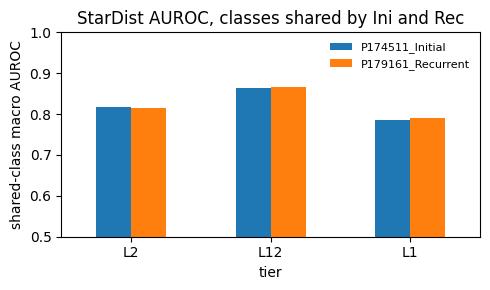

In [4]:
from IPython.display import display

for sample in SAMPLES:
    print(f"\n===== {sample} =====")
    for tier in TIERS:
        spec = stardist_auroc_tier_spec(tier)
        csv_path = STARDIST_RESULT_ROOT / sample / spec["csv_name"]
        names_path = csv_path.with_name(csv_path.name.replace(".csv", "_class_names.csv"))
        if not csv_path.is_file():
            print(f"  missing {csv_path.name}")
            continue
        tab = stardist_per_class_table_from_auroc_csv(csv_path, names_path)
        present = tab.loc[tab["present"]].copy()
        zero_pred = present.loc[present["n_pred"] == 0, "class"].tolist()
        print(
            f"  {tier.upper()}: n={int(present['n'].sum()):,}  "
            f"macro={present['auc_ovr'].mean():.3f}  "
            f"n_pred=0 → {zero_pred or 'none'}"
        )
        display(present.sort_values("n", ascending=False))
        tab.assign(sample=sample, tier=tier.upper()).to_csv(
            OUT_DIR / f"stardist_per_class_{sample}_{tier}.csv", index=False
        )

shared_rows = []
for tier in TIERS:
    spec = stardist_auroc_tier_spec(tier)
    tabs = {}
    for sample in SAMPLES:
        csv_path = STARDIST_RESULT_ROOT / sample / spec["csv_name"]
        names_path = csv_path.with_name(csv_path.name.replace(".csv", "_class_names.csv"))
        if csv_path.is_file():
            tabs[sample] = stardist_per_class_table_from_auroc_csv(csv_path, names_path)
    if len(tabs) < 2:
        continue
    shared = set.intersection(*(set(t.loc[t["present"], "class"]) for t in tabs.values()))
    rec = {"tier": tier.upper(), "n_shared_classes": len(shared)}
    for sample, t in tabs.items():
        rec[sample] = float(t.loc[t["class"].isin(shared) & t["present"], "auc_ovr"].mean())
    shared_rows.append(rec)

shared_df = pd.DataFrame(shared_rows)
print("\nMacro AUROC on classes present in BOTH samples (drops Rec-only G1S/G2M/NPC-like and SN3/4/7):")
display(shared_df)
shared_df.to_csv(OUT_DIR / "stardist_macro_auroc_shared_classes.csv", index=False)

if len(shared_df):
    plot_df = shared_df.set_index("tier")[SAMPLES]
    ax = plot_df.plot(kind="bar", figsize=(5, 3), rot=0)
    ax.set_ylabel("shared-class macro AUROC")
    ax.set_ylim(0.5, 1.0)
    ax.legend(frameon=False, fontsize=8)
    ax.set_title("StarDist AUROC, classes shared by Ini and Rec")
    fig = ax.get_figure()
    fig.tight_layout()
    fig.savefig(OUT_DIR / "stardist_macro_auroc_shared_classes.pdf")
    plt.show()


## Notes

- GBM has no Response / diagnosis / treatment metadata, so this notebook does not run HCC clinical tests.
- Spatial prediction maps are written per replicate under `Results/result_all_spatial/stardist/{P174511_Initial,P179161_Recurrent}/`.
- Palettes: `PAN_ORGAN="codex_gbm"` (WangLab subcluster hierarchy colors).
